## Definitions

In [ ]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-white') # One of the two of these styles will work. not sure why it changes.
import numpy as np
import pandas as pd

In [6]:
def flooxsRead(IVFile):
    IVFile = np.loadtxt(IVFile, delimiter=',')    
    Vds = IVFile[:,0]
    I = IVFile[:,1]
    return Vds,I

## Gate voltage and Peak Field

'\nplt.subplot(1,2,2);\nplt.plot(fieldplate_Vds_nitride, fieldplate_peak_nitride, label="Field Plate Nitride");\nplt.plot(fieldplate_Vds_highk, fieldplate_peak_highk, label="Field Plate HfO2");\nplt.title("Peak Electric Field vs. $V_{DS}, V_{GS}=-4V$", fontsize=20);\nplt.xlabel("$V_{DS} (V)$", fontsize=20);\nplt.ylabel("$E_{peak}$ (${V}/{cm}$)", fontsize=20);\nplt.xticks(fontsize = 18)\nplt.yticks(fontsize = 18)\nplt.grid(True);\nplt.legend();\n#plt.savefig("Vt.png", dpi=300, bbox_inches=\'tight\')\nplt.show()\n'

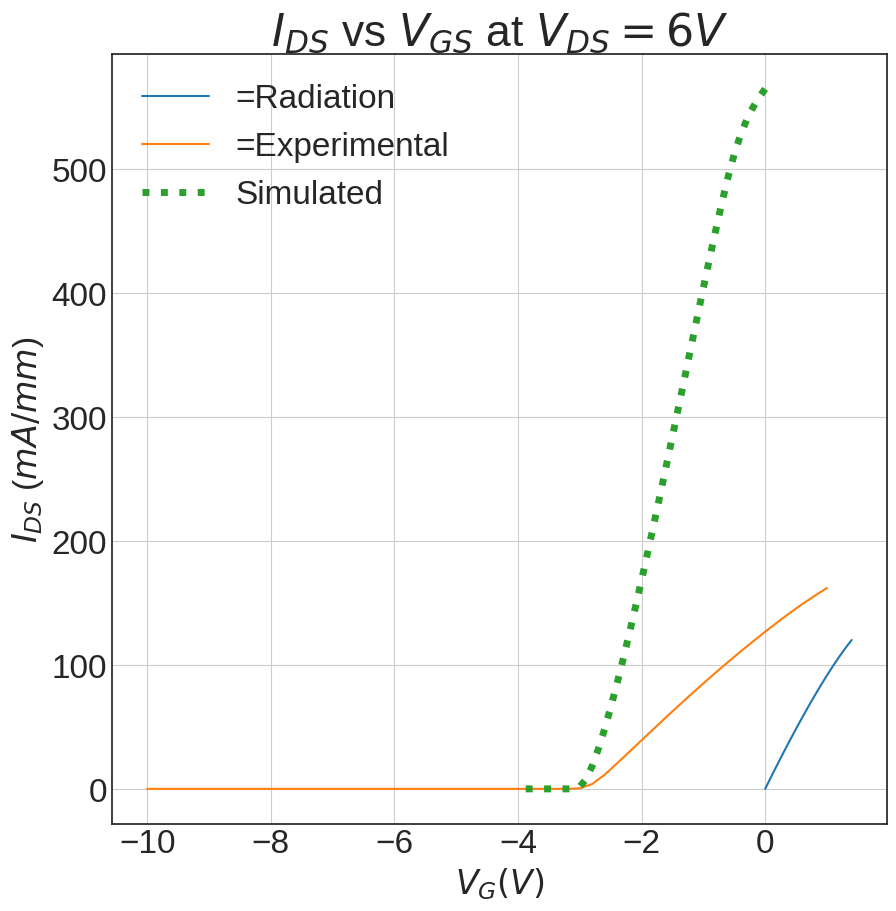

In [7]:
simulated_Vgs, simulated_Ids = flooxsRead("/home/staffian/HEMTRAD/figures/rfDeviceHFO2_Simulated.csv")
experimental_Vgs, experimental_Ids = flooxsRead("/home/staffian/HEMTRAD/figures/rfDeviceHFO2_Experimental.csv")
rad_Vgs, rad_Ids = flooxsRead("/home/staffian/HEMTRAD/figures/radPlot2.csv")


#Plotting IV
plt.figure(figsize=[10,10]);
plt.plot(rad_Vgs, rad_Ids, label="=Radiation");
plt.plot(experimental_Vgs, 1e3*experimental_Ids, label="=Experimental");
plt.plot(simulated_Vgs, 1e3*simulated_Ids, label="Simulated", linewidth='5', linestyle='dotted');
plt.title("$I_{DS}$ vs $V_{GS}$ at $V_{DS}=6V$", fontsize=32);
plt.xlabel("$V_{G} (V)$", fontsize=24);
plt.ylabel("$I_{DS}$ (${mA}/{mm}$)", fontsize=24);
plt.xticks(fontsize = 24)
plt.yticks(fontsize = 24)
plt.grid(True);
plt.legend(fontsize=24)
#plt.savefig("Vt.png", dpi=300, bbox_inches='tight')

IV Curves (Curve tracer type)

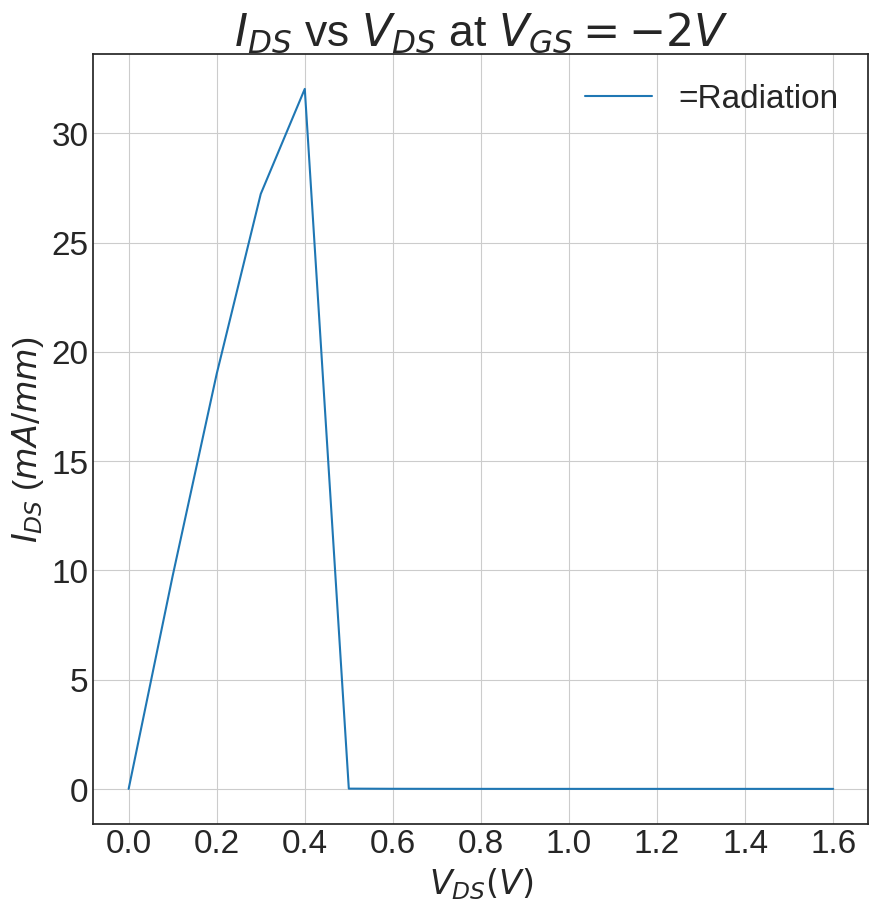

In [ ]:
rad_Vgs, rad_Ids = flooxsRead("/home/staffian/HEMTRAD/figures/radPlot.csv")
rad1_Vgs, rad1_Ids = flooxsRead("/home/staffian/HEMTRAD/figures/radPlot1.csv")

#Plotting IV
plt.figure(figsize=[10,10]);
plt.plot(rad_Vgs, rad_Ids, label="x=0.14");
plt.plot(rad1_Vgs, rad1_Ids, label="x=0.16");
plt.title("$I_{DS}$ vs $V_{DS}$ at $V_{GS}=-2V$", fontsize=32);
plt.xlabel("$V_{DS} (V)$", fontsize=24);
plt.ylabel("$I_{DS}$ (${mA}/{mm}$)", fontsize=24);
plt.xticks(fontsize = 24)
plt.yticks(fontsize = 24)
plt.grid(True);
plt.legend(fontsize=24)
#plt.savefig("Vt.png", dpi=300, bbox_inches='tight')

**Channel Plot Template**

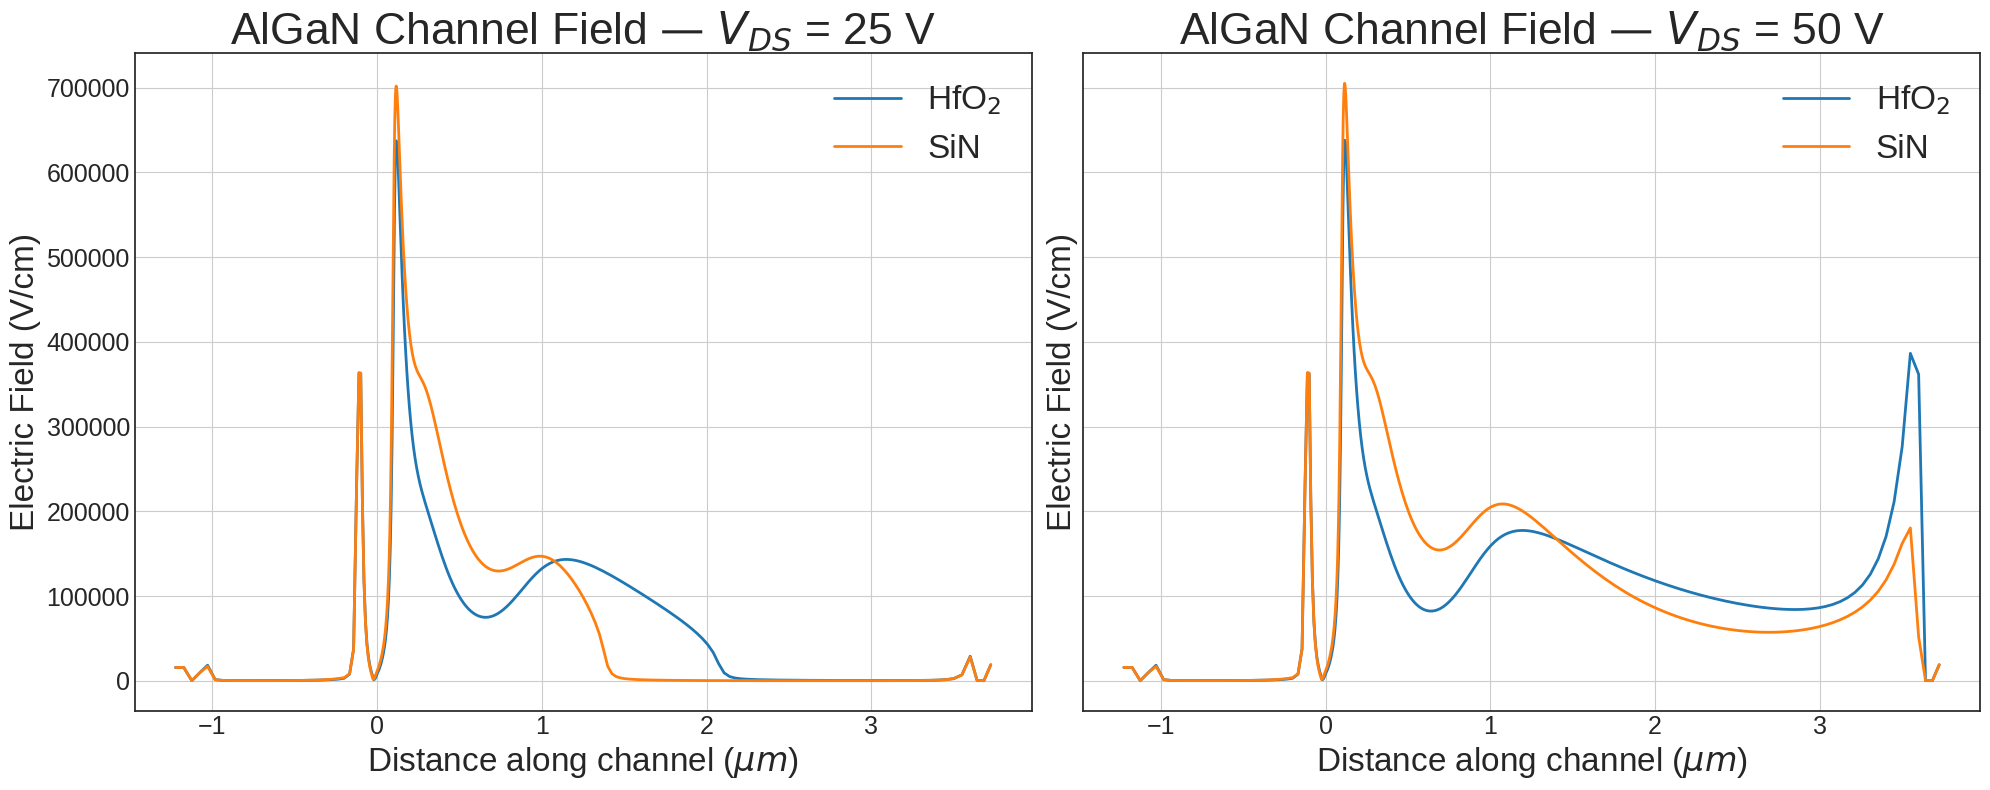

In [12]:
import re

def read_channel_csv(filepath):
    """Read FloOXS channel CSV with multiple voltage sections."""
    sections = []
    current_section = []
    
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                if current_section:
                    sections.append(current_section)
                    current_section = []
                continue
            if 'Distance' in line:
                continue
            # Parse: { value  value  material }
            m = re.match(r'\{\s*([\d.eE+-]+)\s+([\d.eE+-]+)\s+(\w+)\s*\}', line)
            if m:
                current_section.append((float(m.group(1)), float(m.group(2)), m.group(3)))
    if current_section:
        sections.append(current_section)
    return sections

# Voltage values correspond to every 25V from 0 to 50 (Vds = 0, 25, 50)
vds_values = [0, 25, 50]

# =============================================
#  Read both datasets
# =============================================
highk_sections = read_channel_csv("/home/staffian/banjo-wombat/highK/figures/highK_channel.csv")
sin_sections = read_channel_csv("/home/staffian/banjo-wombat/highK/figures/SiN_channel.csv")

fig, axes = plt.subplots(1, 2, figsize=[20, 8], sharey=True)

# Plot Vds=25V (index 1) and Vds=50V (index 2), AlGaN only
for ax, vds_idx, vds in zip(axes, [1, 2], [25, 50]):
    for sec, label in zip([highk_sections[vds_idx], sin_sections[vds_idx]],
                          ["HfO$_2$", "SiN"]):
        distances = np.array([row[0] for row in sec if row[2] == 'AlGaN'])
        field = np.array([row[1] for row in sec if row[2] == 'AlGaN'])
        ax.plot(distances, field, label=label, linewidth=2)

    ax.set_xlabel("Distance along channel ($\\mu m$)", fontsize=24)
    ax.set_ylabel("Electric Field (V/cm)", fontsize=24)
    ax.set_title(f"AlGaN Channel Field — $V_{{DS}}$ = {vds} V", fontsize=32)
    ax.tick_params(labelsize=18)
    ax.legend(fontsize=24)
    ax.grid(True)

plt.tight_layout()
plt.show()

**Stress-then-freeze with hot-electron trap capture** (`stressFreeze.tcl`)

Each curve: hold the quiescent (stress) bias $(V_{GQ}, V_{DQ})$ until the traps settle (hot-electron capture, `HotStress`), freeze the trapped charge, then measure $I_{DS}$-$V_{DS}$ at $V_{GS}=-2V$. Collapse = drop relative to the $(0,0)$ quiescent curve.

Q(0, 10): no data (hotStressIV_q0_10.csv missing)
Q(-4, 20): no data (hotStressIV_qm4_20.csv missing)
I_DS (mA/mm) at V_GS = -2V after each quiescent bias (V_GQ, V_DQ)
         Q(0, 0)  Q(-2, 10)
Vds (V)                    
0.0            0  1.592e-35
1.0        21.06  1.343e-06
2.0        60.68   0.005967
3.0        94.15      1.851
4.0        117.3      17.35
5.0          130      37.61
6.0        136.1      54.33
7.0        139.3      65.46
8.0          141      71.33
9.0        141.8      74.66
10.0       142.3      76.94


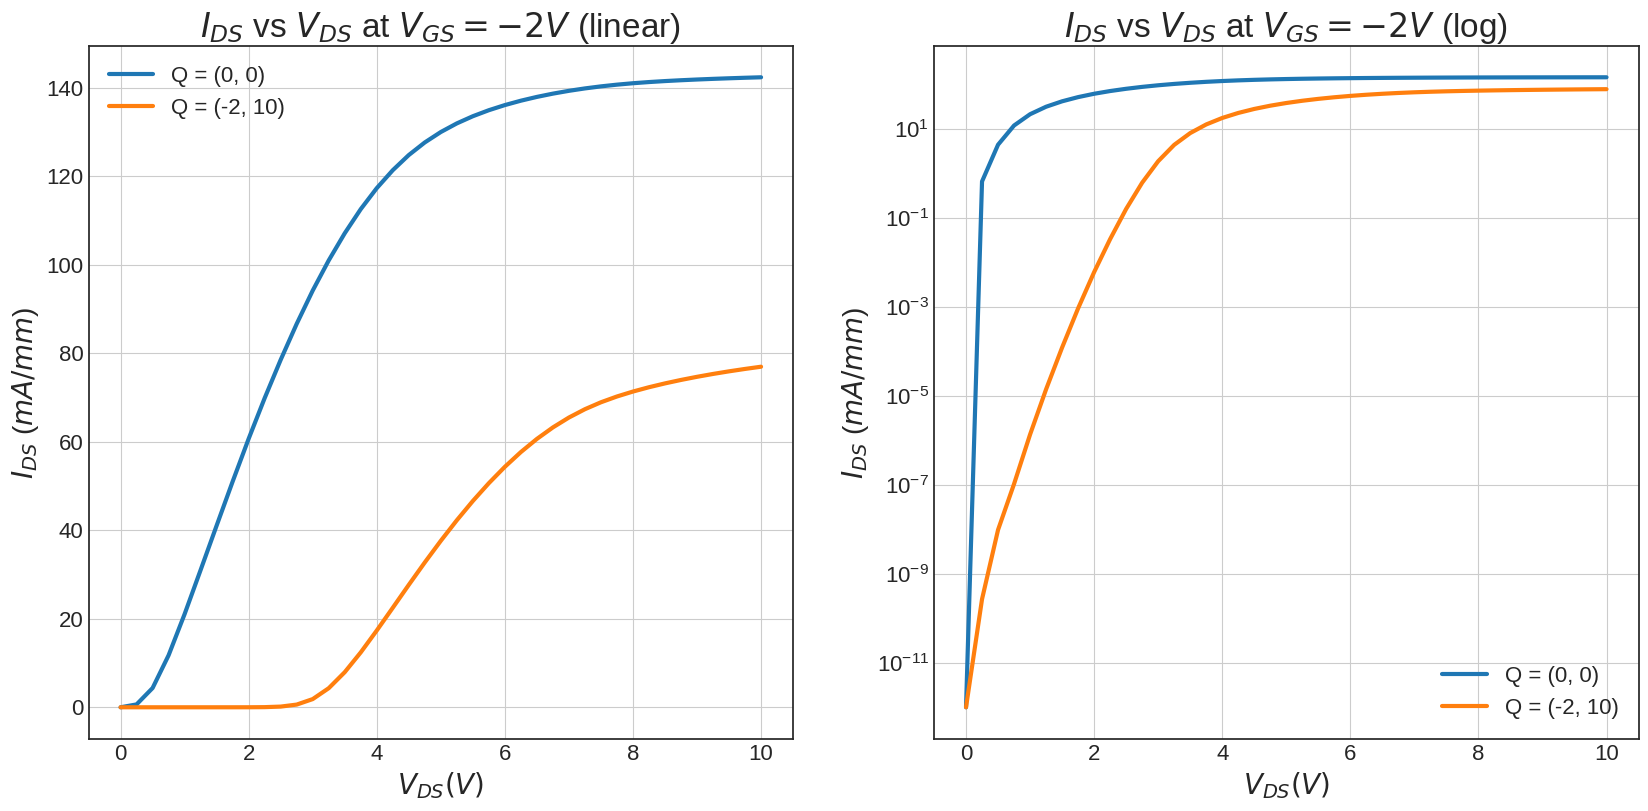

In [14]:
import os

stress = [("(0, 0)", "q0_0"), ("(-2, 10)", "qm2_10"), ("(0, 10)", "q0_10"), ("(-4, 20)", "qm4_20")]
curves = {}
for label, tag in stress:
    path = f"/home/staffian/HEMTRAD/figures/hotStressIV_{tag}.csv"
    if not os.path.exists(path):
        print(f"Q{label}: no data ({os.path.basename(path)} missing)")
        continue
    curves[label] = flooxsRead(path)

table = pd.DataFrame({f"Q{label}": pd.Series(Ids, index=Vds) for label, (Vds, Ids) in curves.items()})
table.index.name = "Vds (V)"
print("I_DS (mA/mm) at V_GS = -2V after each quiescent bias (V_GQ, V_DQ)")
print(table.iloc[::4].to_string(float_format=lambda v: f"{v:.4g}"))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=[20, 9])
for label, (Vds, Ids) in curves.items():
    ax1.plot(Vds, Ids, label=f"Q = {label}", linewidth=3)
    ax2.semilogy(Vds, np.maximum(Ids, 1e-12), label=f"Q = {label}", linewidth=3)
for ax, title in ((ax1, "linear"), (ax2, "log")):
    ax.set_title(f"$I_{{DS}}$ vs $V_{{DS}}$ at $V_{{GS}}=-2V$ ({title})", fontsize=24)
    ax.set_xlabel("$V_{DS} (V)$", fontsize=20)
    ax.set_ylabel("$I_{DS}$ (${mA}/{mm}$)", fontsize=20)
    ax.tick_params(labelsize=16)
    ax.grid(True)
    ax.legend(fontsize=16)
plt.show()

**Pulsed curve-tracer sweep with trap memory: run F** (`pulsedIV.tcl`)

Traps fill from hot-electron capture at each $V_{DS}$ step and cannot emit during the sweep. Run F levers: `trapPeak`=4e18, `trapSigma`=0.04 um, `trapMeanY`=0.20 um, `trapLevel`=0.55 eV, `trapWidth`=0.1 eV, `hotEb`=0.5 eV, `hotTau`=1.3e-13 s, $V_{GS}=-2V$.

 Vds (V)  I_DS run F (mA/mm)  peak Te (K)
       0                   0          300
     0.1               7.802        308.1
     0.2               6.979        437.8
     0.3            0.006314         2997
     0.4            0.002596         3659
     0.5            0.003822         4925
     0.6            0.003089         4254
     0.7            0.004266         5565
     0.8            0.005734         6466
     0.9            0.006098         5210
       1            0.007557         6181
     1.1            0.009327         7262
     1.2             0.01108         7542
     1.3             0.01251         6128
     1.4              0.0142         6659
     1.5             0.01623         7667
     1.6             0.01844         8477


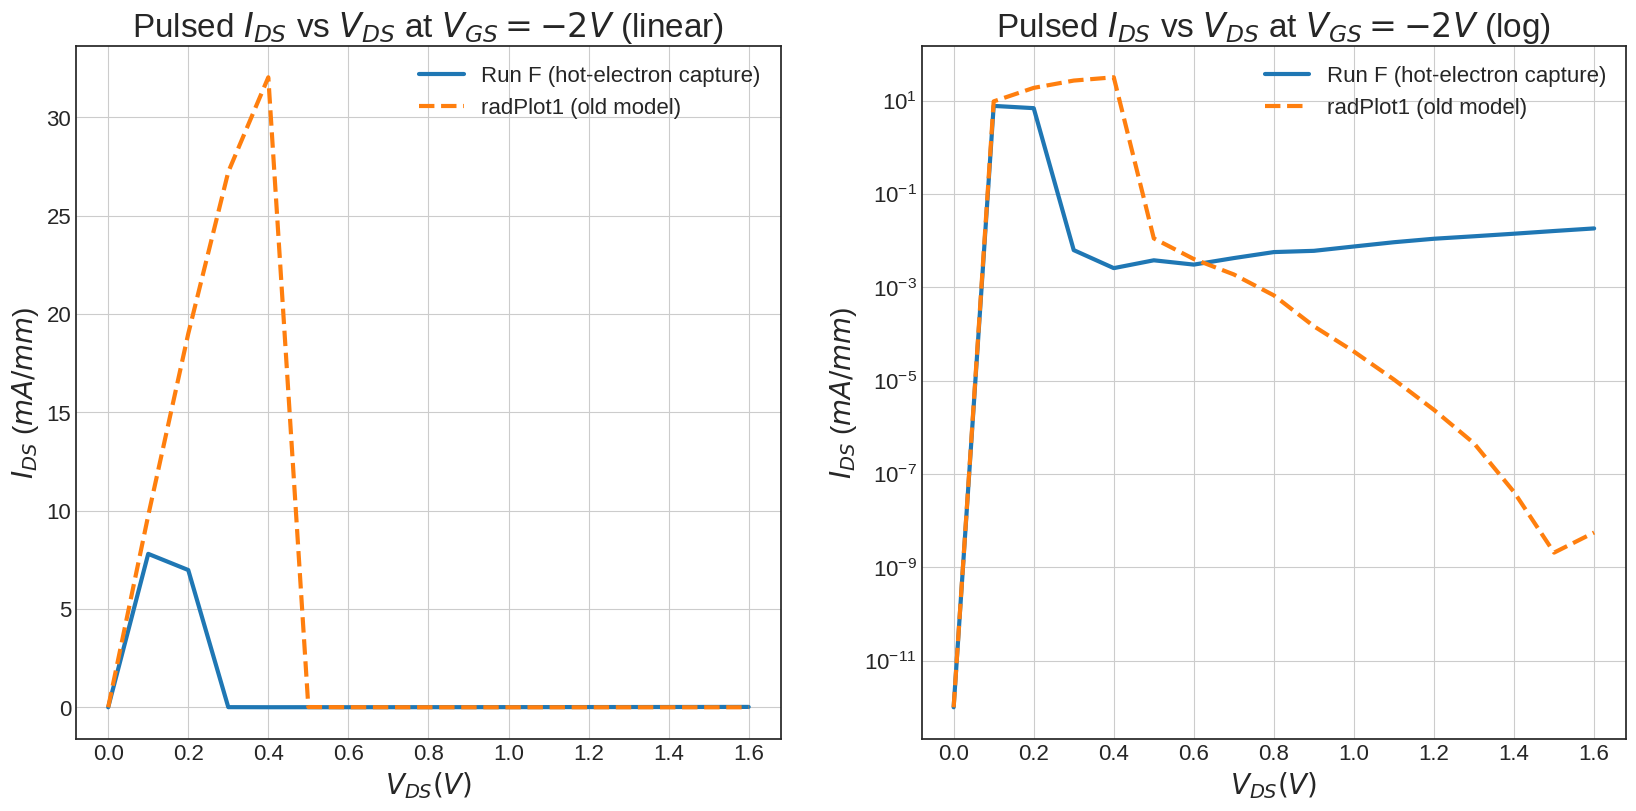

In [1]:
F = np.loadtxt("/home/staffian/HEMTRAD/figures/pulsedIV_F.csv", delimiter=",")
F_Vds, F_Ids, F_Te = F[:, 0], F[:, 1], F[:, 2]
old_Vds, old_Ids = flooxsRead("/home/staffian/HEMTRAD/figures/radPlot1.csv")

print(pd.DataFrame({"Vds (V)": F_Vds, "I_DS run F (mA/mm)": F_Ids, "peak Te (K)": F_Te}).to_string(index=False, float_format=lambda v: f"{v:.4g}"))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=[20, 9])
for ax, plot in ((ax1, ax1.plot), (ax2, ax2.semilogy)):
    plot(F_Vds, np.maximum(F_Ids, 1e-12), label="Run F (hot-electron capture)", linewidth=3)
    plot(old_Vds, np.maximum(old_Ids, 1e-12), label="radPlot1 (old model)", linewidth=3, linestyle="dashed")
    ax.set_xlabel("$V_{DS} (V)$", fontsize=20)
    ax.set_ylabel("$I_{DS}$ (${mA}/{mm}$)", fontsize=20)
    ax.tick_params(labelsize=16)
    ax.grid(True)
    ax.legend(fontsize=16)
ax1.set_title("Pulsed $I_{DS}$ vs $V_{DS}$ at $V_{GS}=-2V$ (linear)", fontsize=24)
ax2.set_title("Pulsed $I_{DS}$ vs $V_{DS}$ at $V_{GS}=-2V$ (log)", fontsize=24)
plt.show()

**Electron mobility model comparison** (`mobilityCompare.tcl`, no traps)

*Static*: constant electron mobility (GaN 600, AlGaN 213.3 cm$^2$/V-s). *Field*: Farahmand low-field mobility (doping and temperature dependent) with high-field saturation along the channel (Heller form in GaN, Farahmand in AlGaN). Selected with `mobModel` in `GaN_modelfile_masterD`.

Static mobility            Id(Vd=10,Vg=0) =   684.3 mA/mm   Id(Vd=1,Vg=0) =  112.7 mA/mm   gm,max =  267.3 mS/mm at Vg = -0.6 V   Vth = -2.57 V
Field-dependent mobility   Id(Vd=10,Vg=0) =   648.6 mA/mm   Id(Vd=1,Vg=0) =  181.9 mA/mm   gm,max =  240.9 mS/mm at Vg = -1.7 V   Vth = -2.80 V


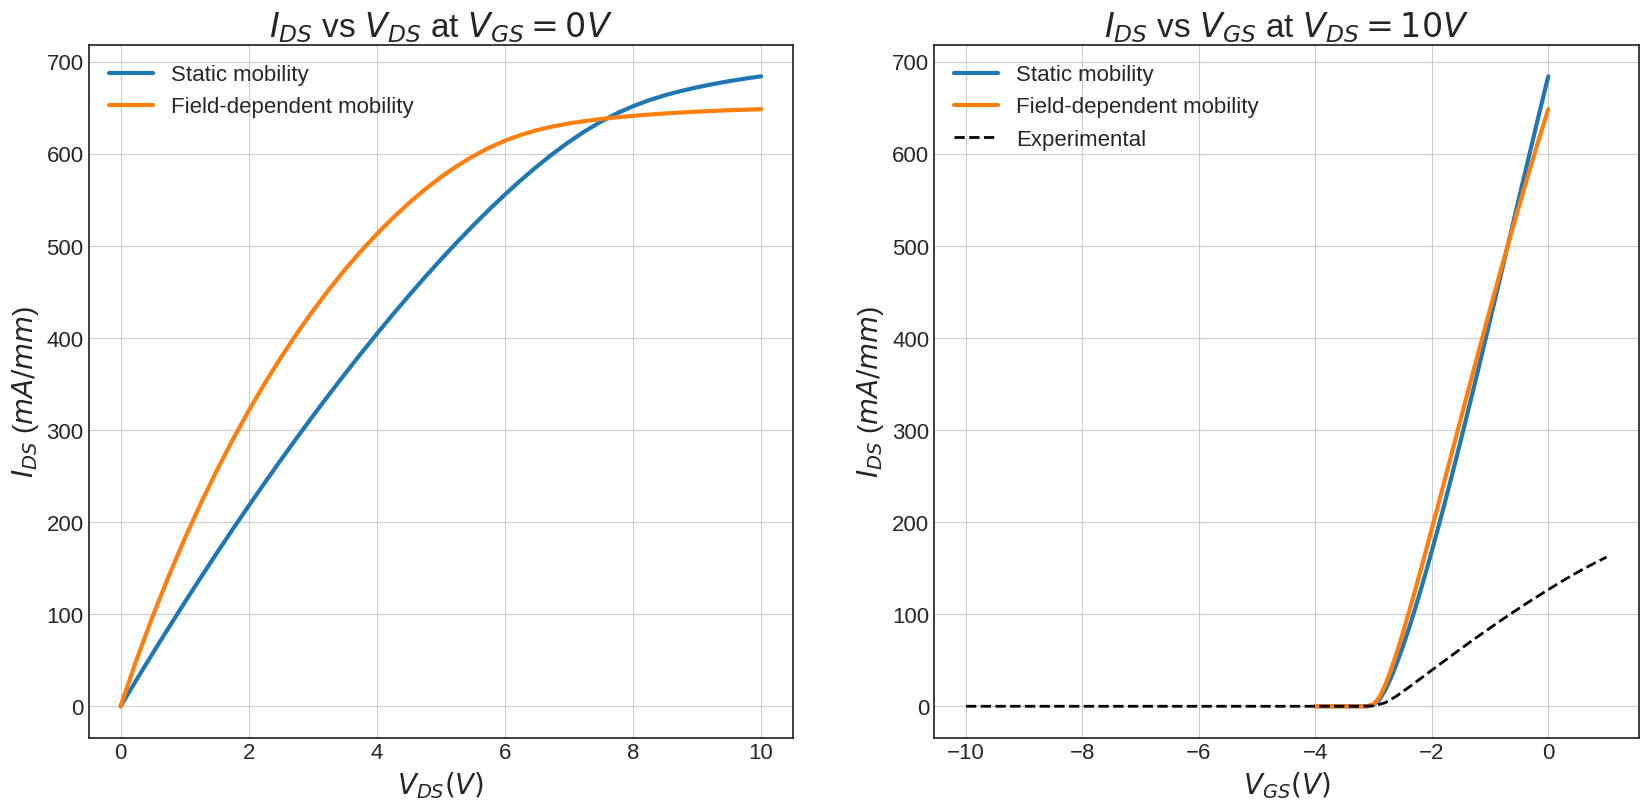

In [1]:
base = "/home/staffian/HEMTRAD/figures/mobility_{}_{}.csv"
models = [("static", "Static mobility"), ("field", "Field-dependent mobility")]
exp_Vgs, exp_Ids = flooxsRead("/home/staffian/HEMTRAD/figures/rfDeviceHFO2_Experimental.csv")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=[20, 9])
for m, label in models:
    Vds, Id = flooxsRead(base.format(m, "IdVd"))
    Vgs, Ig = flooxsRead(base.format(m, "IdVg"))
    ax1.plot(Vds, Id, label=label, linewidth=3)
    ax2.plot(Vgs, Ig, label=label, linewidth=3)
    # peak transconductance and threshold (linear extrapolation at peak gm)
    gm = np.gradient(Ig, Vgs)
    k = np.argmax(gm)
    Vth = Vgs[k] - Ig[k] / gm[k]
    print(f"{label:26s} Id(Vd=10,Vg=0) = {Id[-1]:7.1f} mA/mm   Id(Vd=1,Vg=0) = {Id[4]:6.1f} mA/mm   "
          f"gm,max = {gm[k]:6.1f} mS/mm at Vg = {Vgs[k]:.1f} V   Vth = {Vth:.2f} V")
ax2.plot(exp_Vgs, 1e3 * exp_Ids, "k--", label="Experimental", linewidth=2)

ax1.set_title("$I_{DS}$ vs $V_{DS}$ at $V_{GS}=0V$", fontsize=24)
ax1.set_xlabel("$V_{DS} (V)$", fontsize=20)
ax2.set_title("$I_{DS}$ vs $V_{GS}$ at $V_{DS}=10V$", fontsize=24)
ax2.set_xlabel("$V_{GS} (V)$", fontsize=20)
for ax in (ax1, ax2):
    ax.set_ylabel("$I_{DS}$ (${mA}/{mm}$)", fontsize=20)
    ax.tick_params(labelsize=16)
    ax.grid(True)
    ax.legend(fontsize=16)
plt.show()